<a href="https://colab.research.google.com/github/karanja-dave/crop_disease_prediction_CNN/blob/main/Capstone_EDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubham2703/five-crop-diseases-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.33G/4.33G [00:58<00:00, 80.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shubham2703/five-crop-diseases-dataset/versions/1


In [8]:
import os
from pathlib import Path

# Update the path based on your kagglehub output
new_path = Path('/root/.cache/kagglehub/datasets/shubham2703/five-crop-diseases-dataset/versions/1')

# List the top-level directories to find where the images live
print("Top level folders:", [f.name for f in new_path.iterdir() if f.is_dir()])


Top level folders: ['Crop Diseases Dataset']


Total images found: 13324


Checking dimensions: 100%|██████████| 2000/2000 [00:02<00:00, 740.40it/s]


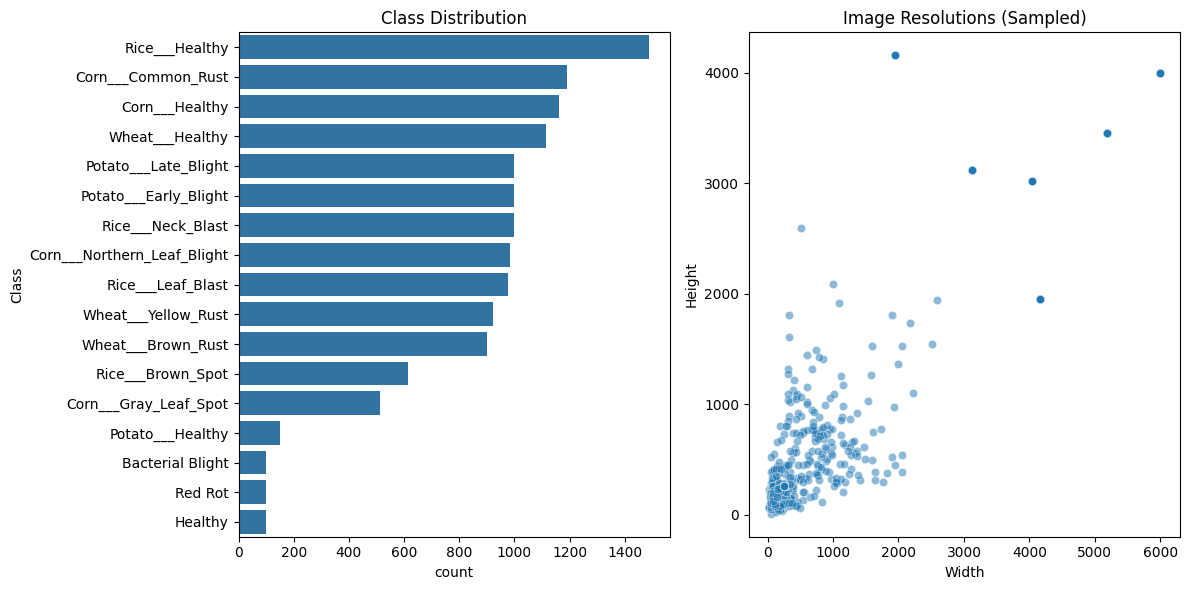

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# 1. Map all files
all_files = list(new_path.glob('**/*.[jJ][pP][gG]'))
print(f"Total images found: {len(all_files)}")

# 2. Fast metadata extraction (Sampling 2000 images for dimension check)
metadata = []
sample_size = min(2000, len(all_files))
import random
sample_files = random.sample(all_files, sample_size)

for img_path in tqdm(sample_files, desc="Checking dimensions"):
    try:
        with Image.open(img_path) as img:
            metadata.append({
                'Class': img_path.parent.name,
                'Width': img.size[0],
                'Height': img.size[1]
            })
    except:
        continue

# 3. Full Class Count (using all files for accuracy)
all_labels = [f.parent.name for f in all_files]
df_labels = pd.DataFrame(all_labels, columns=['Class'])
df_meta = pd.DataFrame(metadata)

# --- Visualizations ---
plt.figure(figsize=(12, 6))

# Class Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df_labels, y='Class', order=df_labels['Class'].value_counts().index)
plt.title('Class Distribution')

# Dimension Consistency
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_meta, x='Width', y='Height', alpha=0.5)
plt.title('Image Resolutions (Sampled)')

plt.tight_layout()
plt.show()


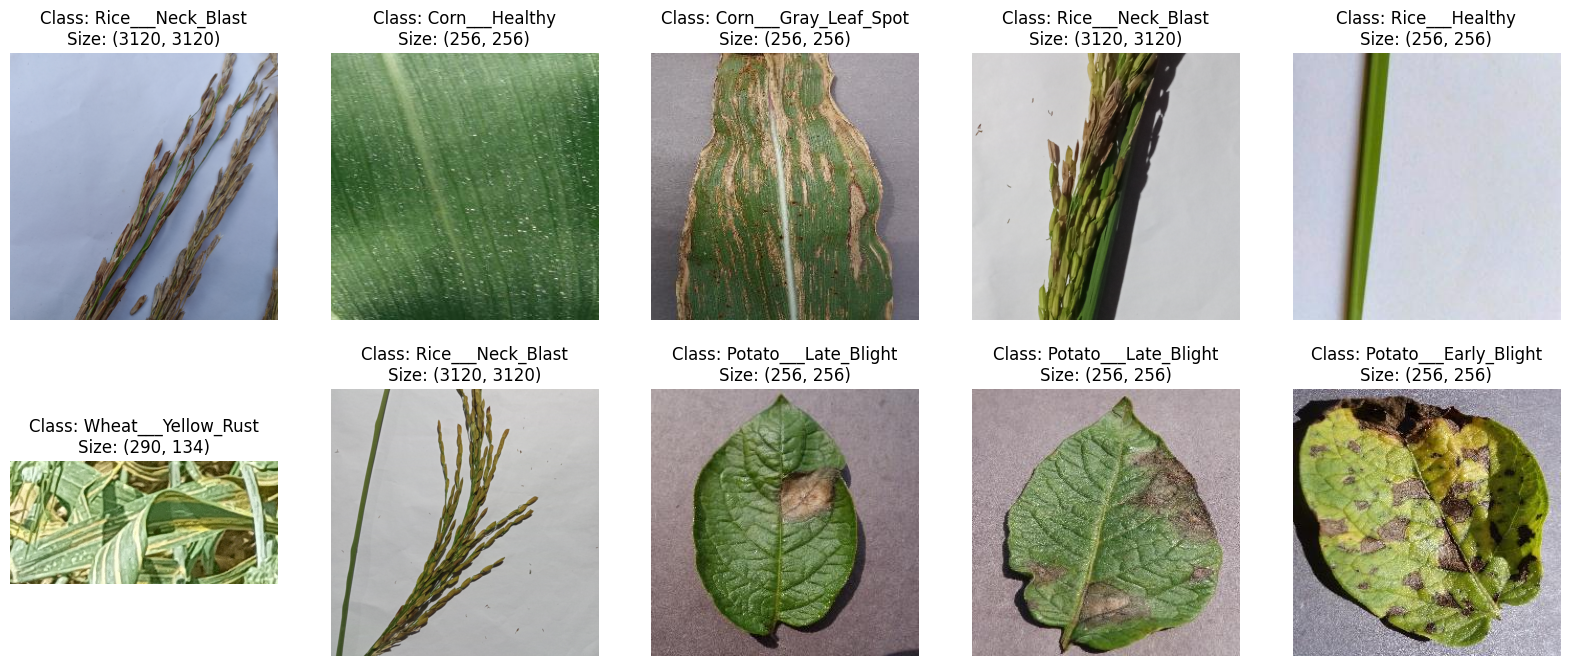

In [10]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_random_samples(image_list, num=10):
    plt.figure(figsize=(20, 8))
    samples = random.sample(image_list, num)
    for i, img_path in enumerate(samples):
        plt.subplot(2, 5, i+1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"Class: {img_path.parent.name}\nSize: {img.size}")
        plt.axis('off')
    plt.show()

plot_random_samples(all_files)


In [11]:
df_meta['Aspect_Ratio'] = df_meta['Width'] / df_meta['Height']
print(df_meta['Aspect_Ratio'].value_counts().head())


Aspect_Ratio
1.000000    1494
1.500000      42
0.469231      31
2.131148      16
1.333333      10
Name: count, dtype: int64


In [12]:
import tensorflow as tf

# 1. Define image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Load and Preprocess
# 'smart_resize' prevents the "squish" by cropping the center of rectangular images
train_ds = tf.keras.utils.image_dataset_from_directory(
    new_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=True # <--- CRITICAL for your mixed aspect ratios
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    new_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=True
)

# 3. Add Data Augmentation to handle different backgrounds
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomContrast(0.1),
])

# Apply augmentation to the training set
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# 4. Optimize Performance (Pre-fetching into RAM)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 13324 files belonging to 1 classes.
Using 10660 files for training.
Found 13324 files belonging to 1 classes.
Using 2664 files for validation.


In [13]:
# Check which folder actually contains the disease subdirectories
import os
for root, dirs, files in os.walk(new_path):
    if len(dirs) > 1:
        print(f"✅ FOUND THE CORRECT DATA DIR: {root}")
        print(f"Classes found: {dirs}")
        correct_data_path = root
        break


✅ FOUND THE CORRECT DATA DIR: /root/.cache/kagglehub/datasets/shubham2703/five-crop-diseases-dataset/versions/1/Crop Diseases Dataset/Crop Diseases/Crop___Disease
Classes found: ['Wheat', 'sugarcane', 'Rice', 'Potato', 'Corn']


In [14]:
import os
# Point to the folder containing the specific crops
crop_root = "/root/.cache/kagglehub/datasets/shubham2703/five-crop-diseases-dataset/versions/1/Crop Diseases Dataset/Crop Diseases/Crop___Disease"

# Check what's inside 'Wheat' (for example)
print("Diseases in Wheat folder:", os.listdir(os.path.join(crop_root, 'Wheat')))


Diseases in Wheat folder: ['Wheat___Brown_Rust', 'Wheat___Yellow_Rust', 'Wheat___Healthy']


In [15]:
import os
from pathlib import Path

# 1. Your base directory that contains 'Wheat', 'Rice', etc.
crop_root = Path("/root/.cache/kagglehub/datasets/shubham2703/five-crop-diseases-dataset/versions/1/Crop Diseases Dataset/Crop Diseases/Crop___Disease")

# 2. Map every disease folder
all_diseases = []
crop_summary = {}

for crop in sorted(os.listdir(crop_root)):
    crop_path = crop_root / crop
    if crop_path.is_dir():
        diseases = [d for d in os.listdir(crop_path) if (crop_path / d).is_dir()]
        all_diseases.extend(diseases)
        crop_summary[crop] = diseases

# 3. Print the results
print(f"✅ Total Disease Classes Found: {len(all_diseases)}\n")
for crop, diseases in crop_summary.items():
    print(f"📍 {crop.upper()}:")
    for d in diseases:
        print(f"  - {d}")
    print("-" * 30)


✅ Total Disease Classes Found: 17

📍 CORN:
  - Corn___Northern_Leaf_Blight
  - Corn___Healthy
  - Corn___Common_Rust
  - Corn___Gray_Leaf_Spot
------------------------------
📍 POTATO:
  - Potato___Late_Blight
  - Potato___Early_Blight
  - Potato___Healthy
------------------------------
📍 RICE:
  - Rice___Healthy
  - Rice___Leaf_Blast
  - Rice___Brown_Spot
  - Rice___Neck_Blast
------------------------------
📍 WHEAT:
  - Wheat___Brown_Rust
  - Wheat___Yellow_Rust
  - Wheat___Healthy
------------------------------
📍 SUGARCANE:
  - Red Rot
  - Healthy
  - Bacterial Blight
------------------------------


Analyzing sample brightness...


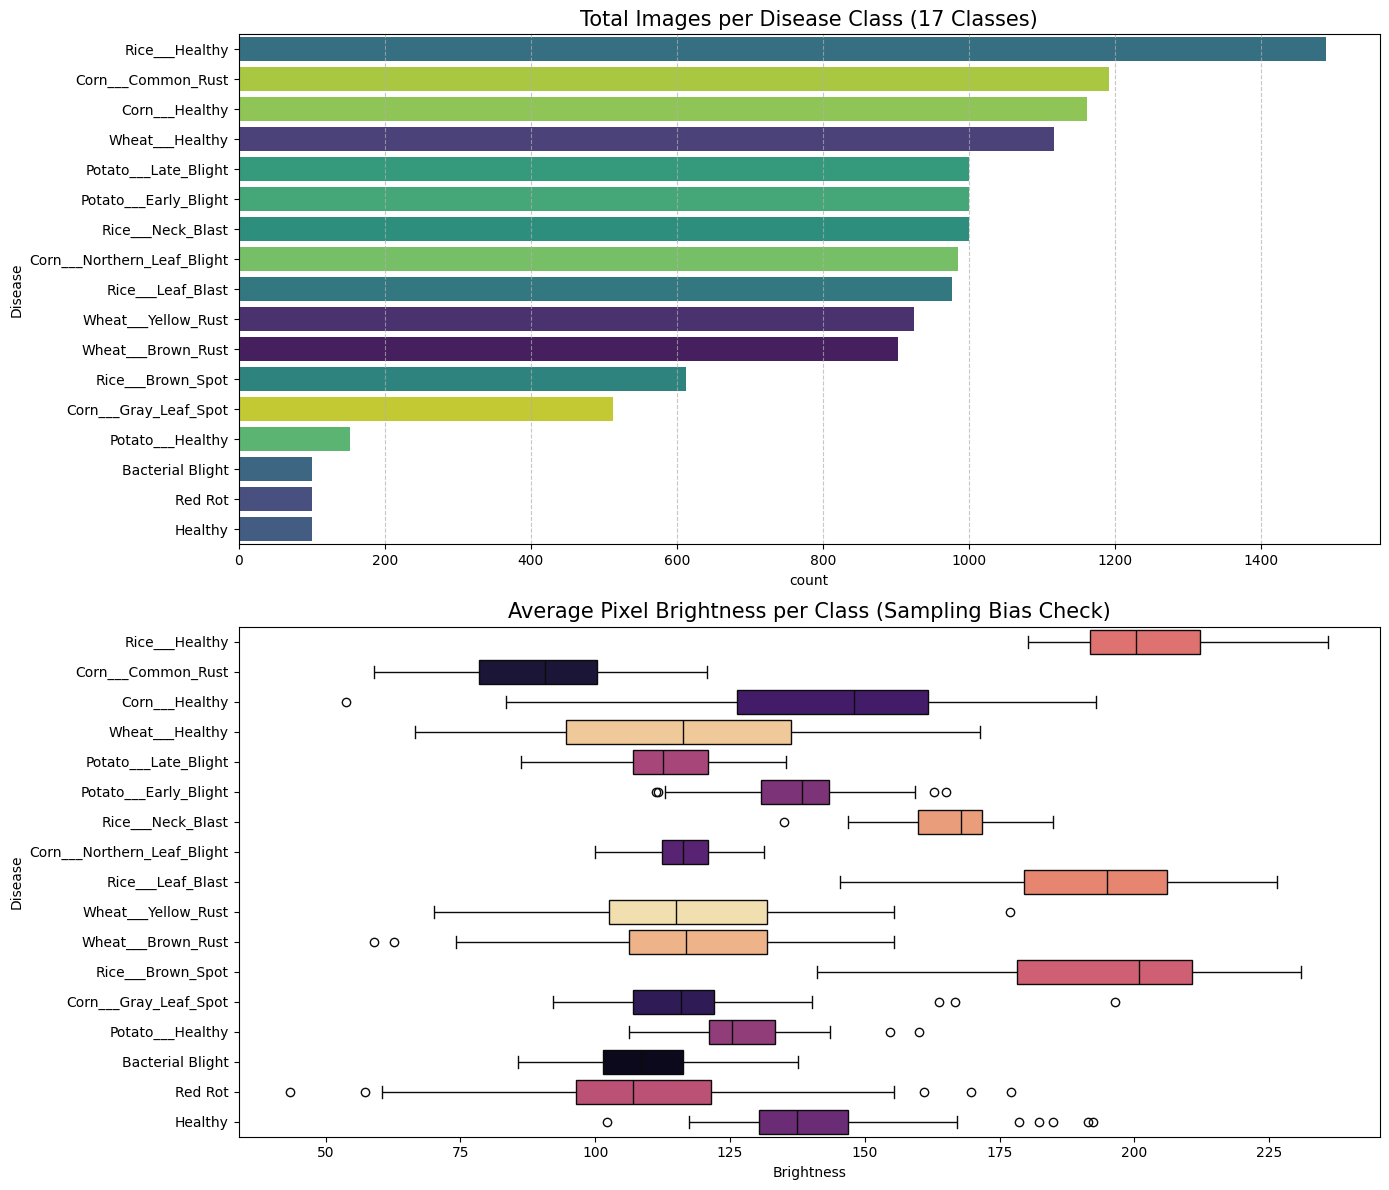


✅ Total Images: 13324
📊 Smallest Class: 100 images
📊 Largest Class: 1488 images


In [16]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm

# 1. Setup Path
root_path = Path("/root/.cache/kagglehub/datasets/shubham2703/five-crop-diseases-dataset/versions/1/Crop Diseases Dataset/Crop Diseases/Crop___Disease")

# 2. Collect Data
data = []
for crop_folder in root_path.iterdir():
    if crop_folder.is_dir():
        for disease_folder in crop_folder.iterdir():
            if disease_folder.is_dir():
                images = list(disease_folder.glob('*.jpg')) + list(disease_folder.glob('*.JPG'))
                for img_path in images:
                    data.append({
                        "Crop": crop_folder.name,
                        "Disease": disease_folder.name,
                        "Path": str(img_path)
                    })

df = pd.DataFrame(data)

# 3. Calculate Brightness for a Sample (to check for lighting bias)
def get_brightness(path):
    with Image.open(path) as img:
        return np.mean(np.array(img.convert('L'))) # Convert to grayscale for brightness

print("Analyzing sample brightness...")
sample_df = df.groupby('Disease').sample(n=min(50, len(df)), replace=False) # 50 pics per class
sample_df['Brightness'] = sample_df['Path'].apply(get_brightness)

# --- VISUALIZATIONS ---

plt.figure(figsize=(14, 12))

# Plot A: Class Distribution (The Bar Chart)
plt.subplot(2, 1, 1)
order = df['Disease'].value_counts().index
sns.countplot(data=df, y='Disease', order=order, palette='viridis', hue='Disease', legend=False)
plt.title('Total Images per Disease Class (17 Classes)', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot B: Brightness Distribution
plt.subplot(2, 1, 2)
sns.boxplot(data=sample_df, x='Brightness', y='Disease', order=order, palette='magma', hue='Disease', legend=False)
plt.title('Average Pixel Brightness per Class (Sampling Bias Check)', fontsize=15)

plt.tight_layout()
plt.show()

# Print Summary Stats
print(f"\n✅ Total Images: {len(df)}")
print(f"📊 Smallest Class: {df['Disease'].value_counts().min()} images")
print(f"📊 Largest Class: {df['Disease'].value_counts().max()} images")


This cell uses the `kagglehub` library to download the 'five-crop-diseases-dataset' from Kaggle. The `path` variable now holds the local directory where the dataset files are extracted, which is essential for accessing the data in subsequent steps.

After downloading the dataset, this cell sets the `new_path` variable to the exact location of the extracted dataset. It then prints the top-level directories within this path, which helps in understanding the initial structure of the downloaded data and identifying where the actual image subfolders might be located.

This cell performs initial Exploratory Data Analysis (EDA) on the image dataset:

1.  **Counts Total Images**: It first gathers all image file paths and reports the total number of images found.
2.  **Samples for Dimension Check**: A sample of 2000 images is taken to quickly extract metadata, specifically image dimensions (width and height), and identifies their respective classes (folder names).
3.  **Class Distribution**: It creates a DataFrame (`df_labels`) to count the occurrences of each class across *all* images and visualizes this distribution using a count plot. This helps identify class imbalances.
4.  **Image Resolution Analysis**: It creates another DataFrame (`df_meta`) from the sampled image metadata and uses a scatter plot to visualize the distribution of image widths and heights. This helps understand if images have consistent dimensions or varied aspect ratios.

The plots give a quick overview of the dataset's structure regarding class balance and image sizing.

This cell defines a function `plot_random_samples` that takes a list of image paths and a number `num` (defaulting to 10). It then randomly selects and displays `num` images, showing their class (parent folder name) and their original dimensions. This provides a visual inspection of the actual images and helps verify that the classes are correctly identified from the folder structure.

Building on the `df_meta` DataFrame (which contains metadata for sampled images), this cell calculates the `Aspect_Ratio` for each image by dividing its width by its height. It then prints the counts of the top 5 most common aspect ratios. This further clarifies the dimension consistency (or inconsistency) across the images, highlighting prevalent image shapes within the dataset.

This cell sets up TensorFlow `image_dataset_from_directory` to load and preprocess the images for a deep learning model:

1.  **Image Parameters**: Defines `IMG_SIZE` (224x224) for resizing and `BATCH_SIZE` (32) for training.
2.  **Dataset Creation**: Creates `train_ds` and `val_ds` (training and validation datasets) directly from the directory structure. It splits the data (80% training, 20% validation) and importantly uses `crop_to_aspect_ratio=True` to handle images with varying aspect ratios by central cropping them to the target `IMG_SIZE` without distortion.
3.  **Data Augmentation**: Defines a `tf.keras.Sequential` model for data augmentation, including random horizontal/vertical flips, rotations, and contrast adjustments. This helps the model generalize better by presenting varied versions of the training images.
4.  **Performance Optimization**: Applies `.cache()` and `.prefetch()` to the datasets. Caching loads data into memory after the first epoch, and prefetching allows the data pipeline to overlap data processing with model execution, significantly speeding up training.

This cell uses `os.walk` to traverse the directory structure starting from `new_path`. Its purpose is to programmatically identify the exact subdirectory that contains the distinct disease classes (e.g., 'Wheat', 'Rice', 'Corn'). It prints the `correct_data_path` once it finds a directory with more than one subdirectory, indicating it has reached the level where crop/disease classifications begin. This is crucial for correctly setting up data loaders later.

After identifying `crop_root`, this cell provides a specific example by listing the contents (disease folders) within the 'Wheat' directory. This verifies that the `crop_root` is indeed the correct base and illustrates the naming convention for the disease classes within each crop type.

This cell comprehensively maps the entire dataset structure. It iterates through each crop folder within `crop_root`, then lists all disease subfolders within each crop. It populates `all_diseases` with a flat list of all unique disease class names and `crop_summary` with a dictionary mapping each crop to its specific diseases. Finally, it prints a neatly formatted summary showing the total number of distinct disease classes and the breakdown of diseases under each crop, providing a complete overview of the dataset's categorical structure.

This comprehensive cell performs several critical steps for data understanding:

1.  **Data Collection**: It iterates through the `crop_root` to collect all image paths, their corresponding crop, and disease labels, storing this information in a Pandas DataFrame (`df`).
2.  **Brightness Analysis**: It defines a function `get_brightness` to calculate the average pixel intensity (brightness) of an image. To efficiently check for lighting biases, it samples 50 images from each disease class, calculates their brightness, and stores this in `sample_df`.
3.  **Visualizations**:
    *   **Class Distribution**: A count plot (`Plot A`) shows the number of images per disease class, reinforcing the class balance insights.
    *   **Brightness Distribution**: A box plot (`Plot B`) displays the distribution of brightness values for each disease class. This is a crucial check for potential lighting biases; if certain classes are consistently brighter or darker, it could influence model performance.
4.  **Summary Statistics**: It prints the total number of images and the minimum/maximum images found in any single disease class, giving a quantitative summary of dataset size and class balance extremes.